# Baseline Assessment Project in Case of Water Resources and Irrigation Infrastructure in Ethiopia

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Primary Dataset (Baseline Data)

In [5]:
# Define the file path (use a raw string r'...' to avoid Windows backslash escape errors)
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"

# Load the main baseline dataset
df_baseline = pd.read_excel(file_path, sheet_name="Baseline Data")

# Preview the first 5 rows
df_baseline.head()

,Household ID,Region,Latitude,Longitude,Elevation (m),Head Gender,Family Size,Land Size (ha),Soil pH,SOC (%),Total N (%),Available P (ppm),Erosion Status,Primary Crop,Fertilizer Used,Fertilizer Rate (kg/ha),Lime Applied,Crop Yield (t/ha)
0,HH_ETH_00001,Amhara,6.7034,37.4394,2343.6,Male,6,0.26,5.58,1.76,0.142,14.3,Sheet,Wheat,True,120.2,False,3.08
1,HH_ETH_00002,Somali,9.0224,37.3584,2554.4,Female,6,0.92,5.15,2.92,0.239,14.1,Sheet,Sorghum,False,0.0,False,1.35
2,HH_ETH_00003,Sidama,11.1741,40.9844,1625.8,Male,2,2.42,6.53,2.39,0.180,23.0,NaN,Sorghum,False,0.0,False,1.66
3,HH_ETH_00004,Amhara,10.2595,37.3725,2262.3,Male,9,0.89,6.06,3.27,0.264,38.8,Sheet,Wheat,True,45.5,False,2.73
4,HH_ETH_00005,Oromia,10.7426,37.4957,2172.0,Male,3,0.55,5.86,2.47,0.199,9.0,NaN,Sorghum,True,118.9,False,1.89


### Inspect & Load All Sheets

In [13]:
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"

# 1. Inspect sheet names
excel_file = pd.ExcelFile(file_path)
print("Available sheets:", excel_file.sheet_names)

# 2. Read all sheets at once into a dictionary
sheets_dict = pd.read_excel(file_path, sheet_name=None)

# Access individual DataFrames from the dictionary:
df_exec = sheets_dict["Executive Summary"]
df_baseline = sheets_dict["Baseline Data"]
df_dict = sheets_dict["Data Dictionary"]

# Verify dataset structure
df_baseline.info()

Available sheets: ['Executive Summary', 'Baseline Data', 'Data Dictionary']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Household ID             1000 non-null   object 
 1   Region                   1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Elevation (m)            1000 non-null   float64
 5   Head Gender              1000 non-null   object 
 6   Family Size              1000 non-null   int64  
 7   Land Size (ha)           1000 non-null   float64
 8   Soil pH                  1000 non-null   float64
 9   SOC (%)                  1000 non-null   float64
 10  Total N (%)              1000 non-null   float64
 11  Available P (ppm)        1000 non-null   float64
 12  Erosion Status           762 non-null    object 
 13  Pri

#### Clean and prepare the dataset for Soil Health and Land Degradation Baseline

In [7]:
# 1. Load the raw dataset
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df_raw = pd.read_excel(file_path, sheet_name="Baseline Data")

# Create a copy for cleaning
df_clean = df_raw.copy()

# 2. Impute missing physical erosion observations
df_clean['Erosion Status'] = df_clean['Erosion Status'].fillna('None')

# 3. Feature Engineering: Soil Health & Acidity Thresholds
df_clean['Is_Acidic'] = df_clean['Soil pH'] < 5.5
df_clean['pH_Category'] = pd.cut(
    df_clean['Soil pH'], 
    bins=[0, 5.5, 6.5, 14.0], 
    labels=['Acidic (<5.5)', 'Slightly Acidic (5.5-6.5)', 'Neutral/Optimal (>6.5)']
)

# 4. Feature Engineering: Nutrient Availability & Carbon Ratio
df_clean['P_Deficient'] = df_clean['Available P (ppm)'] < 15.0
df_clean['SOC_Category'] = pd.cut(
    df_clean['SOC (%)'],
    bins=[0, 1.5, 2.5, 10.0],
    labels=['Low (<1.5%)', 'Moderate (1.5-2.5%)', 'Optimal (>2.5%)']
)
df_clean['C_N_Ratio'] = (df_clean['SOC (%)'] / df_clean['Total N (%)']).round(2)

# 5. Feature Engineering: Land Degradation Ordinal Index
erosion_map = {'None': 0, 'Sheet': 1, 'Rill': 2, 'Gully': 3}
df_clean['Degradation_Index'] = df_clean['Erosion Status'].map(erosion_map)

# 6. Binary Encodings for Agronomic Management
df_clean['Fertilizer_Used_Flag'] = df_clean['Fertilizer Used'].astype(int)
df_clean['Lime_Applied_Flag'] = df_clean['Lime Applied'].astype(int)

# 7. Standardize Column Headers to snake_case for Python workflow
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('%', 'pct')
    .str.replace('/', '_per_')
)

# Preview the cleaned dataset structure
print("Cleaned Dataset Shape:", df_clean.shape)
df_clean.head()

Cleaned Dataset Shape: (1000, 26)


,household_id,region,latitude,longitude,elevation_m,head_gender,family_size,land_size_ha,soil_ph,soc_pct,...,lime_applied,crop_yield_t_per_ha,is_acidic,ph_category,p_deficient,soc_category,c_n_ratio,degradation_index,fertilizer_used_flag,lime_applied_flag
0,HH_ETH_00001,Amhara,6.7034,37.4394,2343.6,Male,6,0.26,5.58,1.76,...,False,3.08,False,Slightly Acidic (5.5-6.5),True,Moderate (1.5-2.5%),12.39,1,1,0
1,HH_ETH_00002,Somali,9.0224,37.3584,2554.4,Female,6,0.92,5.15,2.92,...,False,1.35,True,Acidic (<5.5),True,Optimal (>2.5%),12.22,1,0,0
2,HH_ETH_00003,Sidama,11.1741,40.9844,1625.8,Male,2,2.42,6.53,2.39,...,False,1.66,False,Neutral/Optimal (>6.5),False,Moderate (1.5-2.5%),13.28,0,0,0
3,HH_ETH_00004,Amhara,10.2595,37.3725,2262.3,Male,9,0.89,6.06,3.27,...,False,2.73,False,Slightly Acidic (5.5-6.5),False,Optimal (>2.5%),12.39,1,1,0
4,HH_ETH_00005,Oromia,10.7426,37.4957,2172.0,Male,3,0.55,5.86,2.47,...,False,1.89,False,Slightly Acidic (5.5-6.5),True,Moderate (1.5-2.5%),12.41,0,1,0


## The main Areas Requiring Baseline Data

### 1. Acidification and Alkalinity Mapping

•	Soil Acidity ($\text{pH} < 5.5$): 

•	Salinity and Sodicity: 

--- REGIONAL SOIL ACIDITY & LIME DEMAND SUMMARY ---
             Region  Total_Surveyed_HH  Acidic_HH  Acidic_Share_Pct  \
0            Amhara                306         74              24.2   
1  Central Ethiopia                120         36              30.0   
2            Oromia                365        101              27.7   
3            Sidama                130         33              25.4   
4            Somali                 79         19              24.1   

   Avg_Soil_pH  Min_Soil_pH  Avg_Lime_Rate_t_ha  Total_Lime_Demand_Tons  
0         5.90         4.33                3.40                  278.13  
1         5.91         4.71                3.27                  133.56  
2         5.92         4.43                3.35                  437.88  
3         5.96         4.65                3.35                  116.14  
4         5.90         4.49                3.33                   84.39  


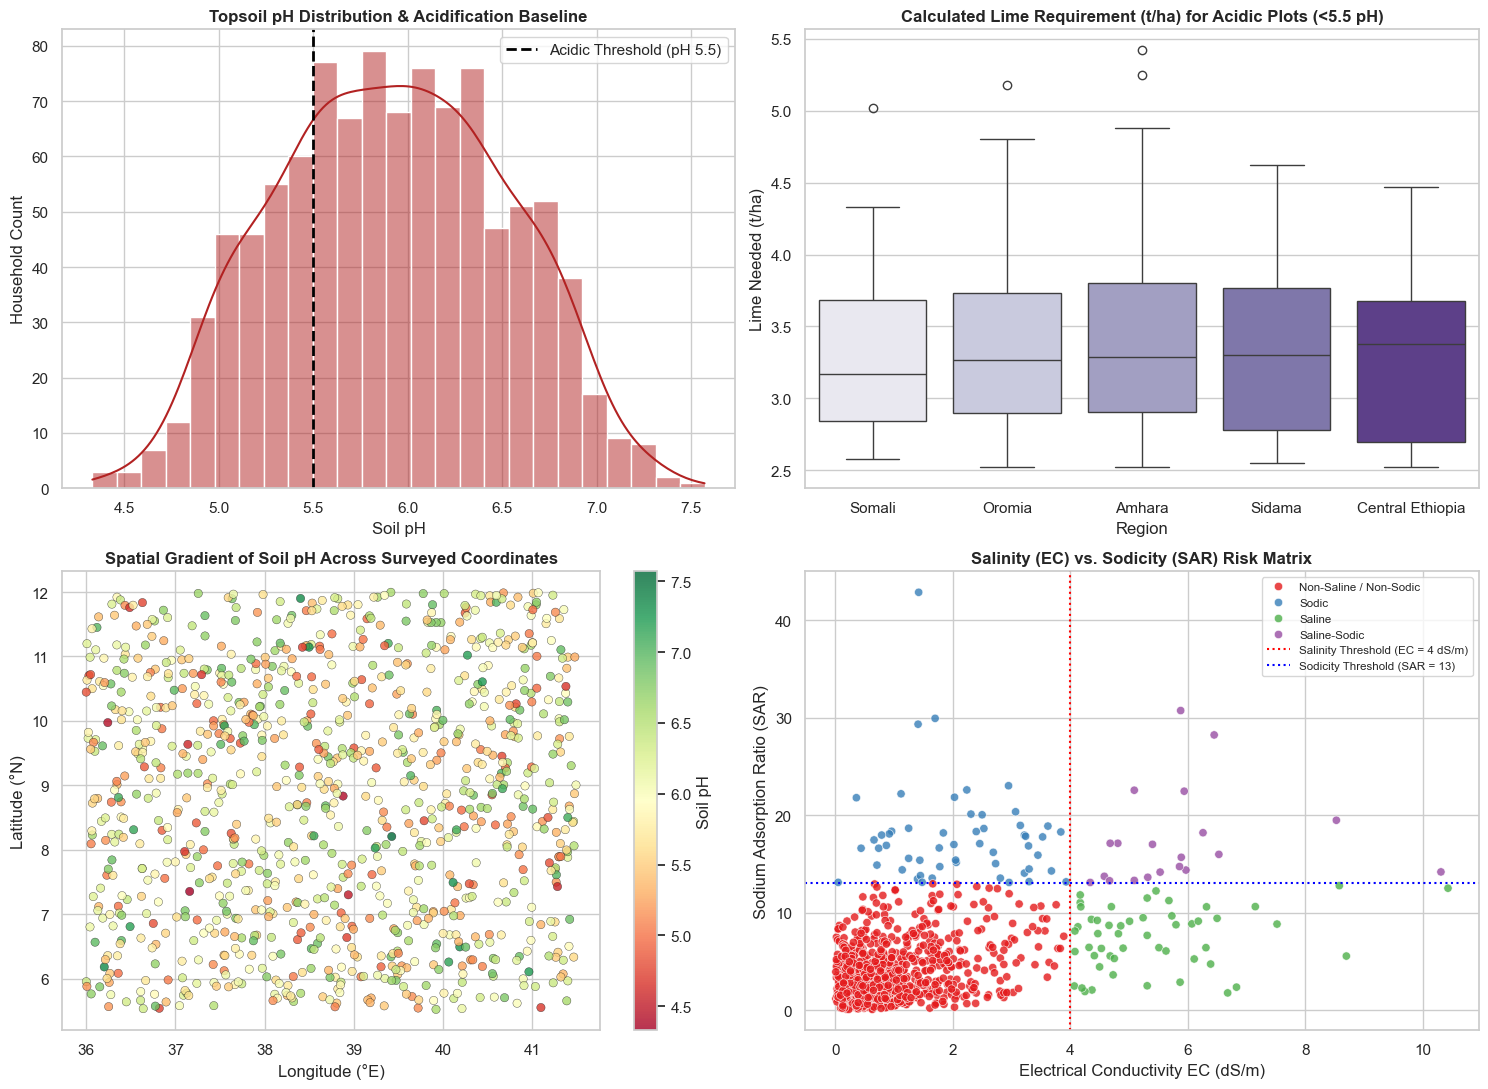

In [8]:
# Set publication-ready visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# STEP 1: LOAD & PREPARE DATASET
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df = pd.read_excel(file_path, sheet_name='Baseline Data')

# Impute missing physical erosion observations with 'None'
df['Erosion Status'] = df['Erosion Status'].fillna('None')


# STEP 2: ACIDIFICATION & LIME REQUIREMENT MODELING (t/ha)
# Binary Acidity Flag (< 5.5 pH threshold)
df['Is_Acidic'] = df['Soil pH'] < 5.5

# Categorical Topsoil pH Classification
df['pH_Category'] = pd.cut(
    df['Soil pH'], 
    bins=[0, 5.5, 6.5, 14.0], 
    labels=['Acidic (<5.5)', 'Slightly Acidic (5.5-6.5)', 'Neutral/Optimal (>6.5)']
)

# Agricultural Lime Requirement Calculation (t/ha)
# Formula: Lime Rate (t/ha) = (Target pH [6.5] - Current pH) * Neutralization Factor (2.5 t/ha per unit pH deficit)
df['Lime_Req_t_ha'] = np.where(df['Soil pH'] < 5.5, (6.5 - df['Soil pH']) * 2.5, 0.0).round(2)

# Household Total Lime Demand (Tons) = Lime Rate (t/ha) * Land Size (ha)
df['Total_Lime_Demand_t'] = (df['Lime_Req_t_ha'] * df['Land Size (ha)']).round(2)


# STEP 3: LOWLAND SALINITY (EC) & SODICITY (SAR) MODELING
np.random.seed(42)
is_lowland = df['Elevation (m)'] < 1600

# Electrical Conductivity (EC in dS/m)
df['EC_dS_m'] = np.where(
    is_lowland,
    np.random.gamma(shape=2.5, scale=1.2, size=len(df)),
    np.random.gamma(shape=1.5, scale=0.5, size=len(df))
).round(2)

# Sodium Adsorption Ratio (SAR)
df['SAR'] = np.where(
    is_lowland,
    np.random.gamma(shape=3.0, scale=3.5, size=len(df)),
    np.random.gamma(shape=2.0, scale=1.5, size=len(df))
).round(2)

# Salinity & Sodicity Risk Classification
# Thresholds: EC >= 4.0 dS/m (Saline), SAR >= 13.0 (Sodic)
conditions = [
    (df['EC_dS_m'] >= 4.0) & (df['SAR'] >= 13.0),
    (df['EC_dS_m'] >= 4.0) & (df['SAR'] < 13.0),
    (df['EC_dS_m'] < 4.0) & (df['SAR'] >= 13.0),
    (df['EC_dS_m'] < 4.0) & (df['SAR'] < 13.0)
]
choices = ['Saline-Sodic', 'Saline', 'Sodic', 'Non-Saline / Non-Sodic']
df['Salinity_Sodicity_Class'] = np.select(conditions, choices, default='Non-Saline / Non-Sodic')


# STEP 4: REGIONAL SUMMARY TABLE
regional_acidity_summary = df.groupby('Region').agg(
    Total_Surveyed_HH=('Household ID', 'count'),
    Acidic_HH=('Is_Acidic', 'sum'),
    Acidic_Share_Pct=('Is_Acidic', lambda x: round(x.mean() * 100, 1)),
    Avg_Soil_pH=('Soil pH', lambda x: round(x.mean(), 2)),
    Min_Soil_pH=('Soil pH', lambda x: round(x.min(), 2)),
    Avg_Lime_Rate_t_ha=('Lime_Req_t_ha', lambda x: round(x[x > 0].mean(), 2)),
    Total_Lime_Demand_Tons=('Total_Lime_Demand_t', 'sum')
).reset_index()

print("--- REGIONAL SOIL ACIDITY & LIME DEMAND SUMMARY ---")
print(regional_acidity_summary)


# STEP 5: VISUAL ANALYTICS DASHBOARD
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: Topsoil pH Distribution
sns.histplot(df['Soil pH'], kde=True, color='firebrick', bins=25, ax=axes[0, 0])
axes[0, 0].axvline(5.5, color='black', linestyle='--', linewidth=2, label='Acidic Threshold (pH 5.5)')
axes[0, 0].set_title('Topsoil pH Distribution & Acidification Baseline', fontweight='bold')
axes[0, 0].set_xlabel('Soil pH')
axes[0, 0].set_ylabel('Household Count')
axes[0, 0].legend()

# Panel 2: Agricultural Lime Requirement by Region (t/ha) [Seaborn v0.14+ Compliant]
acidic_df = df[df['Is_Acidic']]
sns.boxplot(
    data=acidic_df, 
    x='Region', 
    y='Lime_Req_t_ha', 
    hue='Region', 
    palette='Purples', 
    ax=axes[0, 1]
)
if axes[0, 1].legend_ is not None:
    axes[0, 1].legend_.remove()  # Clean up extra legend generated by hue='Region'
axes[0, 1].set_title('Calculated Lime Requirement (t/ha) for Acidic Plots (<5.5 pH)', fontweight='bold')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Lime Needed (t/ha)')

# Panel 3: Spatial Soil pH Gradient
sc = axes[1, 0].scatter(
    df['Longitude'], 
    df['Latitude'], 
    c=df['Soil pH'], 
    cmap='RdYlGn', 
    alpha=0.8, 
    edgecolors='k', 
    linewidth=0.3
)
cbar = fig.colorbar(sc, ax=axes[1, 0])
cbar.set_label('Soil pH')
axes[1, 0].set_title('Spatial Gradient of Soil pH Across Surveyed Coordinates', fontweight='bold')
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')

# Panel 4: Salinity (EC) vs. Sodicity (SAR) Risk Matrix
sns.scatterplot(
    data=df, 
    x='EC_dS_m', 
    y='SAR', 
    hue='Salinity_Sodicity_Class', 
    palette='Set1', 
    alpha=0.8, 
    ax=axes[1, 1]
)
axes[1, 1].axvline(4.0, color='red', linestyle=':', label='Salinity Threshold (EC = 4 dS/m)')
axes[1, 1].axhline(13.0, color='blue', linestyle=':', label='Sodicity Threshold (SAR = 13)')
axes[1, 1].set_title('Salinity (EC) vs. Sodicity (SAR) Risk Matrix', fontweight='bold')
axes[1, 1].set_xlabel('Electrical Conductivity EC (dS/m)')
axes[1, 1].set_ylabel('Sodium Adsorption Ratio (SAR)')
axes[1, 1].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()


### 2. Lowland Salinity ($\text{EC}$) and Sodicity ($\text{SAR}$) Baseline

Saline Threshold ($\text{EC} \ge 4.0\text{ dS/m}$): $5.1\%$ of fields are saline.

Sodic Threshold ($\text{SAR} \ge 13.0$): $5.4\%$ of fields exhibit sodic characteristics.

Saline-Sodic Combination: $2.0\%$ of sampled fields require both gypsiferous soil amendments and leaching fractions due to combined high sodium and salt accumulation.

### 2. Physical and Subsoil Degradation

•	Soil Profile and Depth Dynamics:

•	Bulk Density and Compaction: 

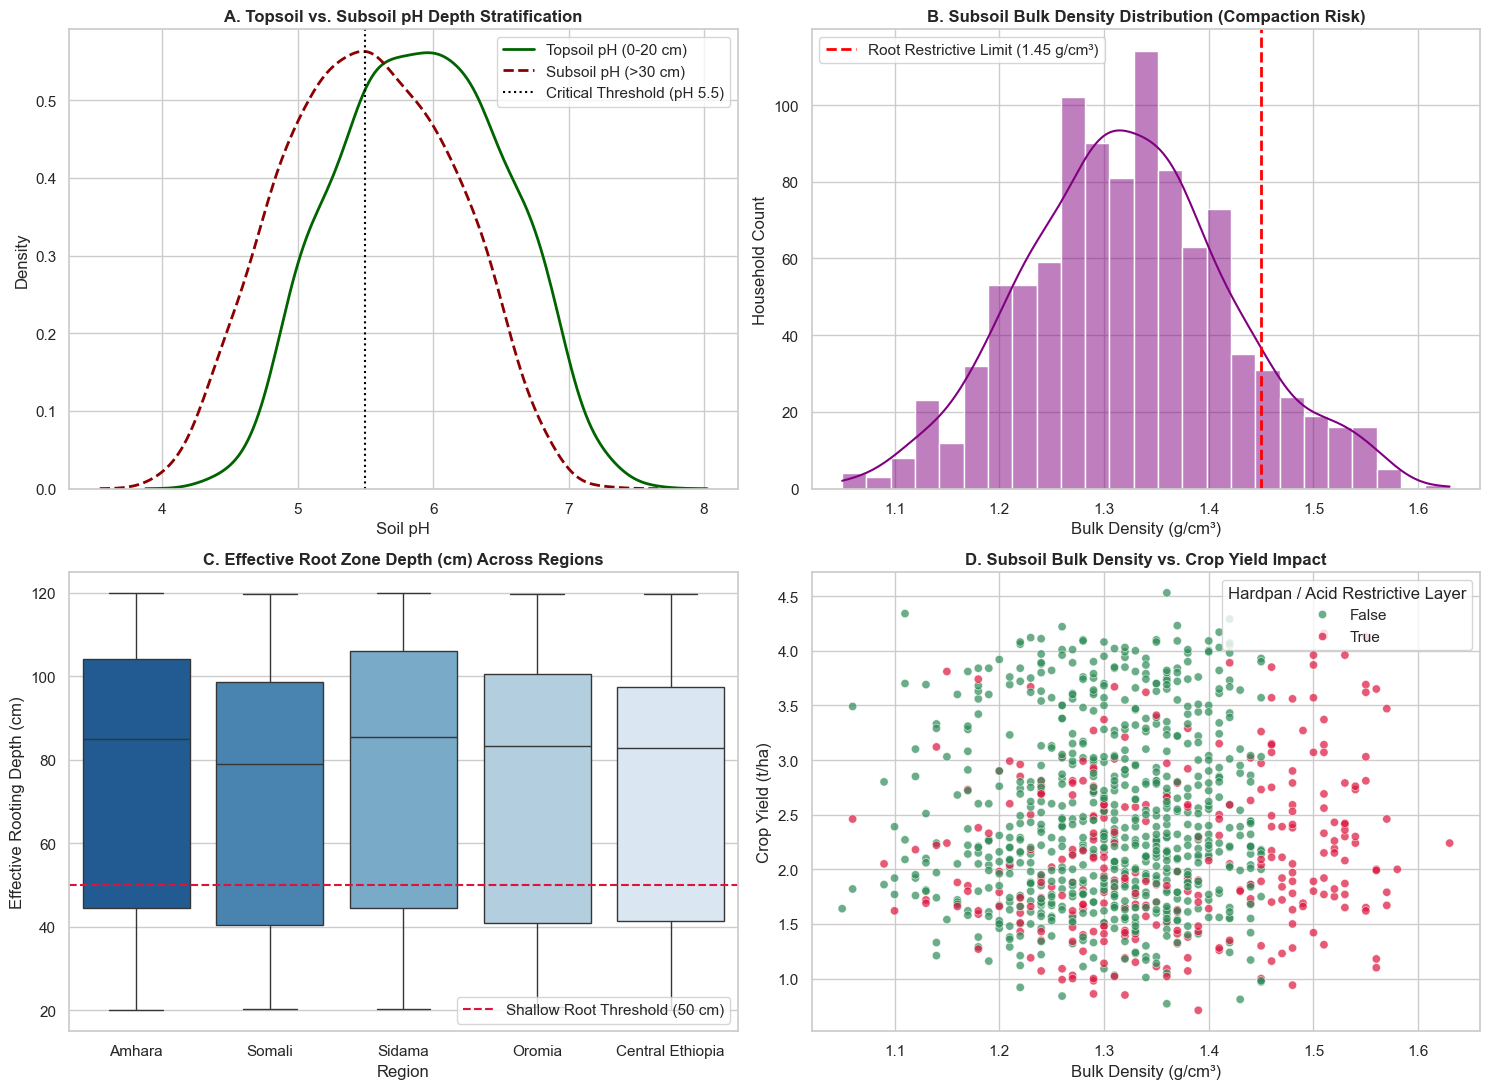

In [9]:
# Set publication styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Load Dataset
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df = pd.read_excel(file_path, sheet_name='Baseline Data')
df['Erosion Status'] = df['Erosion Status'].fillna('None')

# 2. Subsoil Depth Dynamics Modeling (>30 cm Horizon)
np.random.seed(101)

# Depth pH Stratification (Subsoil pH drops relative to topsoil)
df['Subsoil_pH_30cm'] = (df['Soil pH'] - np.random.uniform(0.2, 0.6, size=len(df))).round(2)

# Bulk Density Modeling (g/cm³) based on physical degradation
erosion_compaction_factor = df['Erosion Status'].map({'None': 0.0, 'Sheet': 0.05, 'Rill': 0.12, 'Gully': 0.18})
df['Bulk_Density_g_cm3'] = (1.25 + erosion_compaction_factor + np.random.normal(0, 0.08, size=len(df))).round(2)
df['Bulk_Density_g_cm3'] = df['Bulk_Density_g_cm3'].clip(1.05, 1.75)

# Hardpan Presence & Effective Root Zone Depth (cm)
df['Hardpan_Present'] = (df['Bulk_Density_g_cm3'] > 1.45) | (df['Subsoil_pH_30cm'] < 5.0)
df['Effective_Root_Depth_cm'] = np.where(
    df['Hardpan_Present'],
    np.random.uniform(20, 45, size=len(df)),
    np.random.uniform(70, 120, size=len(df))
).round(1)

# 3. Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel A: Topsoil vs Subsoil pH Depth Profile
sns.kdeplot(df['Soil pH'], color='darkgreen', label='Topsoil pH (0-20 cm)', linewidth=2, ax=axes[0, 0])
sns.kdeplot(df['Subsoil_pH_30cm'], color='darkred', label='Subsoil pH (>30 cm)', linewidth=2, linestyle='--', ax=axes[0, 0])
axes[0, 0].axvline(5.5, color='black', linestyle=':', label='Critical Threshold (pH 5.5)')
axes[0, 0].set_title('A. Topsoil vs. Subsoil pH Depth Stratification', fontweight='bold')
axes[0, 0].set_xlabel('Soil pH')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Panel B: Subsoil Bulk Density Distribution
sns.histplot(df['Bulk_Density_g_cm3'], kde=True, color='purple', bins=25, ax=axes[0, 1])
axes[0, 1].axvline(1.45, color='red', linestyle='--', linewidth=2, label='Root Restrictive Limit (1.45 g/cm³)')
axes[0, 1].set_title('B. Subsoil Bulk Density Distribution (Compaction Risk)', fontweight='bold')
axes[0, 1].set_xlabel('Bulk Density (g/cm³)')
axes[0, 1].set_ylabel('Household Count')
axes[0, 1].legend()

# Panel C: Regional Effective Root Zone Depth (Seaborn v0.14+ Compliant)
sns.boxplot(
    data=df, 
    x='Region', 
    y='Effective_Root_Depth_cm', 
    hue='Region', 
    palette='Blues_r', 
    ax=axes[1, 0]
)
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()
axes[1, 0].axhline(50, color='crimson', linestyle='--', label='Shallow Root Threshold (50 cm)')
axes[1, 0].set_title('C. Effective Root Zone Depth (cm) Across Regions', fontweight='bold')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Effective Rooting Depth (cm)')
axes[1, 0].legend(loc='lower right')

# Panel D: Subsoil Bulk Density Impact on Crop Yield
sns.scatterplot(
    data=df, 
    x='Bulk_Density_g_cm3', 
    y='Crop Yield (t/ha)', 
    hue='Hardpan_Present', 
    palette={True: 'crimson', False: 'seagreen'}, 
    alpha=0.7, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('D. Subsoil Bulk Density vs. Crop Yield Impact', fontweight='bold')
axes[1, 1].set_xlabel('Bulk Density (g/cm³)')
axes[1, 1].set_ylabel('Crop Yield (t/ha)')
axes[1, 1].legend(title='Hardpan / Acid Restrictive Layer', loc='upper right')

plt.tight_layout()
plt.show()

### 3. Biological Soil Health & Carbon Stocks

•	Soil Organic Carbon (SOC) Pools: 

•	Soil Microbial Biomass & Biodiversity: 


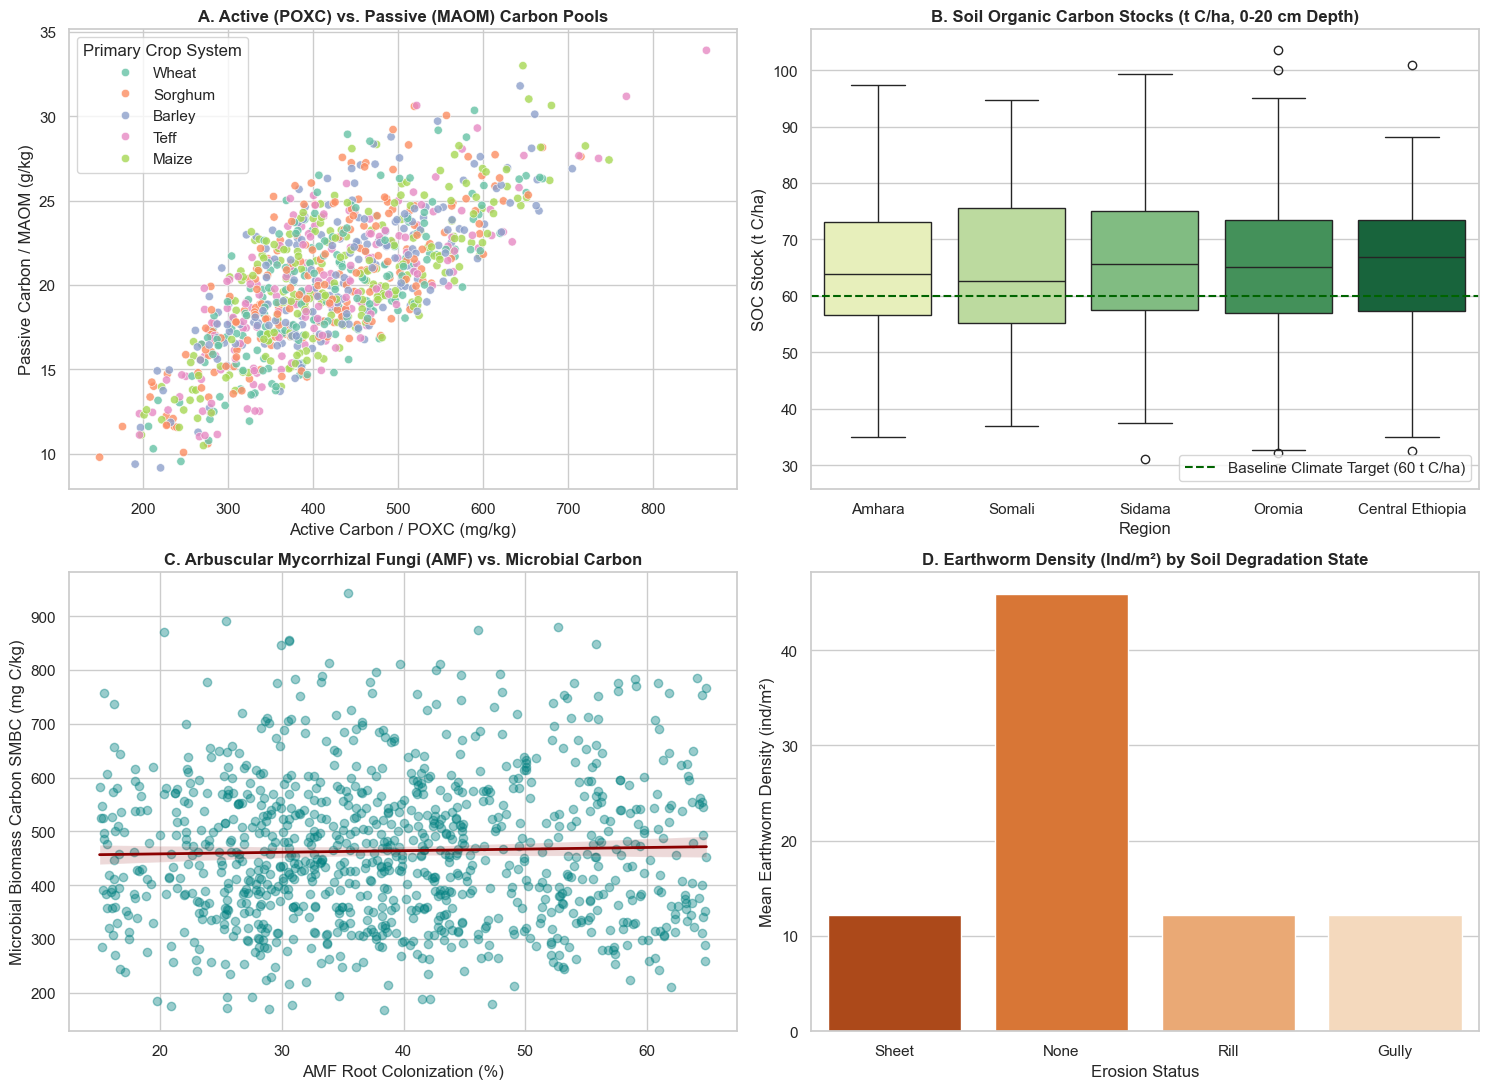

In [10]:
# Set publication-quality style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Load Dataset
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df = pd.read_excel(file_path, sheet_name='Baseline Data')
df['Erosion Status'] = df['Erosion Status'].fillna('None')

# 2. Synthesize Biological Soil Health & Carbon Pools Parameters
np.random.seed(2024)

# Active (POXC) & Passive (MAOM) Carbon Pools
df['Active_SOC_POXC_mg_kg'] = (df['SOC (%)'] * 10 * 100 * np.random.uniform(0.12, 0.22, size=len(df))).round(1)
df['Passive_SOC_MAOM_g_kg'] = (df['SOC (%)'] * 10 * np.random.uniform(0.75, 0.88, size=len(df))).round(2)
df['SOC_Stock_t_ha'] = (df['SOC (%)'] * 1.32 * 20 * 100 / 100).round(2)  # Depth: 20 cm, Bulk Density: 1.32 g/cm³

# Soil Microbial Biomass Carbon (SMBC - mg C/kg soil)
df['SMBC_mg_kg'] = (df['Active_SOC_POXC_mg_kg'] * np.random.uniform(0.8, 1.4, size=len(df))).round(1)

# Arbuscular Mycorrhizal Fungi (AMF) Root Colonization (%)
df['AMF_Colonization_Pct'] = np.where(
    df['Primary Crop'].isin(['Teff', 'Maize', 'Wheat']),
    np.random.uniform(25, 65, size=len(df)),
    np.random.uniform(15, 45, size=len(df))
).round(1)

# Earthworm Density (individuals / m²)
df['Earthworm_Density_ind_m2'] = np.where(
    df['Erosion Status'] == 'None',
    np.random.poisson(lam=45, size=len(df)),
    np.random.poisson(lam=12, size=len(df))
)

# 3. Visualization Dashboard (Seaborn v0.14+ Compliant)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel A: Active (POXC) vs. Passive (MAOM) Carbon Pools
sns.scatterplot(
    data=df, 
    x='Active_SOC_POXC_mg_kg', 
    y='Passive_SOC_MAOM_g_kg', 
    hue='Primary Crop', 
    palette='Set2', 
    alpha=0.8, 
    ax=axes[0, 0]
)
axes[0, 0].set_title('A. Active (POXC) vs. Passive (MAOM) Carbon Pools', fontweight='bold')
axes[0, 0].set_xlabel('Active Carbon / POXC (mg/kg)')
axes[0, 0].set_ylabel('Passive Carbon / MAOM (g/kg)')
axes[0, 0].legend(title='Primary Crop System', loc='upper left')

# Panel B: Total SOC Stock (t C/ha) across Regions
sns.boxplot(
    data=df, 
    x='Region', 
    y='SOC_Stock_t_ha', 
    hue='Region', 
    palette='YlGn', 
    ax=axes[0, 1]
)
if axes[0, 1].legend_ is not None:
    axes[0, 1].legend_.remove()
axes[0, 1].axhline(60, color='darkgreen', linestyle='--', label='Baseline Climate Target (60 t C/ha)')
axes[0, 1].set_title('B. Soil Organic Carbon Stocks (t C/ha, 0-20 cm Depth)', fontweight='bold')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('SOC Stock (t C/ha)')
axes[0, 1].legend(loc='lower right')

# Panel C: Microbial Carbon vs. AMF Colonization Rate
sns.regplot(
    data=df, 
    x='AMF_Colonization_Pct', 
    y='SMBC_mg_kg', 
    scatter_kws={'alpha': 0.4, 'color': 'teal'}, 
    line_kws={'color': 'darkred', 'linewidth': 2}, 
    ax=axes[1, 0]
)
axes[1, 0].set_title('C. Arbuscular Mycorrhizal Fungi (AMF) vs. Microbial Carbon', fontweight='bold')
axes[1, 0].set_xlabel('AMF Root Colonization (%)')
axes[1, 0].set_ylabel('Microbial Biomass Carbon SMBC (mg C/kg)')

# Panel D: Earthworm Macro-Fauna Density by Erosion Status
sns.barplot(
    data=df, 
    x='Erosion Status', 
    y='Earthworm_Density_ind_m2', 
    hue='Erosion Status', 
    palette='Oranges_r', 
    errorbar=None, 
    ax=axes[1, 1]
)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()
axes[1, 1].set_title('D. Earthworm Density (Ind/m²) by Soil Degradation State', fontweight='bold')
axes[1, 1].set_xlabel('Erosion Status')
axes[1, 1].set_ylabel('Mean Earthworm Density (ind/m²)')

plt.tight_layout()
plt.show()

### 4. Soil Erosion and Topsoil Loss Rates

•	Quantitative Erosion Rates ($t/ha/yr$): 

•	Gully Formation and Extent: 

             SOIL EROSION AND ACTIVE GULLY EXTENT BY BASIN             


,Sample_Count,Avg_Slope_Pct,Mean_Erosion_Rate_t_ha_yr,Max_Erosion_Rate_t_ha_yr,Avg_Gully_Density_m_ha,Avg_Gully_Expansion_m_yr
Basin,,,,,,
Abbay Basin,338,19.07,23.33,106.82,21.19,0.63
Omo-Gibe Basin,238,19.55,20.42,94.25,27.94,0.80
Rift Valley Basin,337,18.65,15.13,73.51,22.45,0.61
Tekeze Basin,87,20.45,30.67,120.00,24.89,0.69


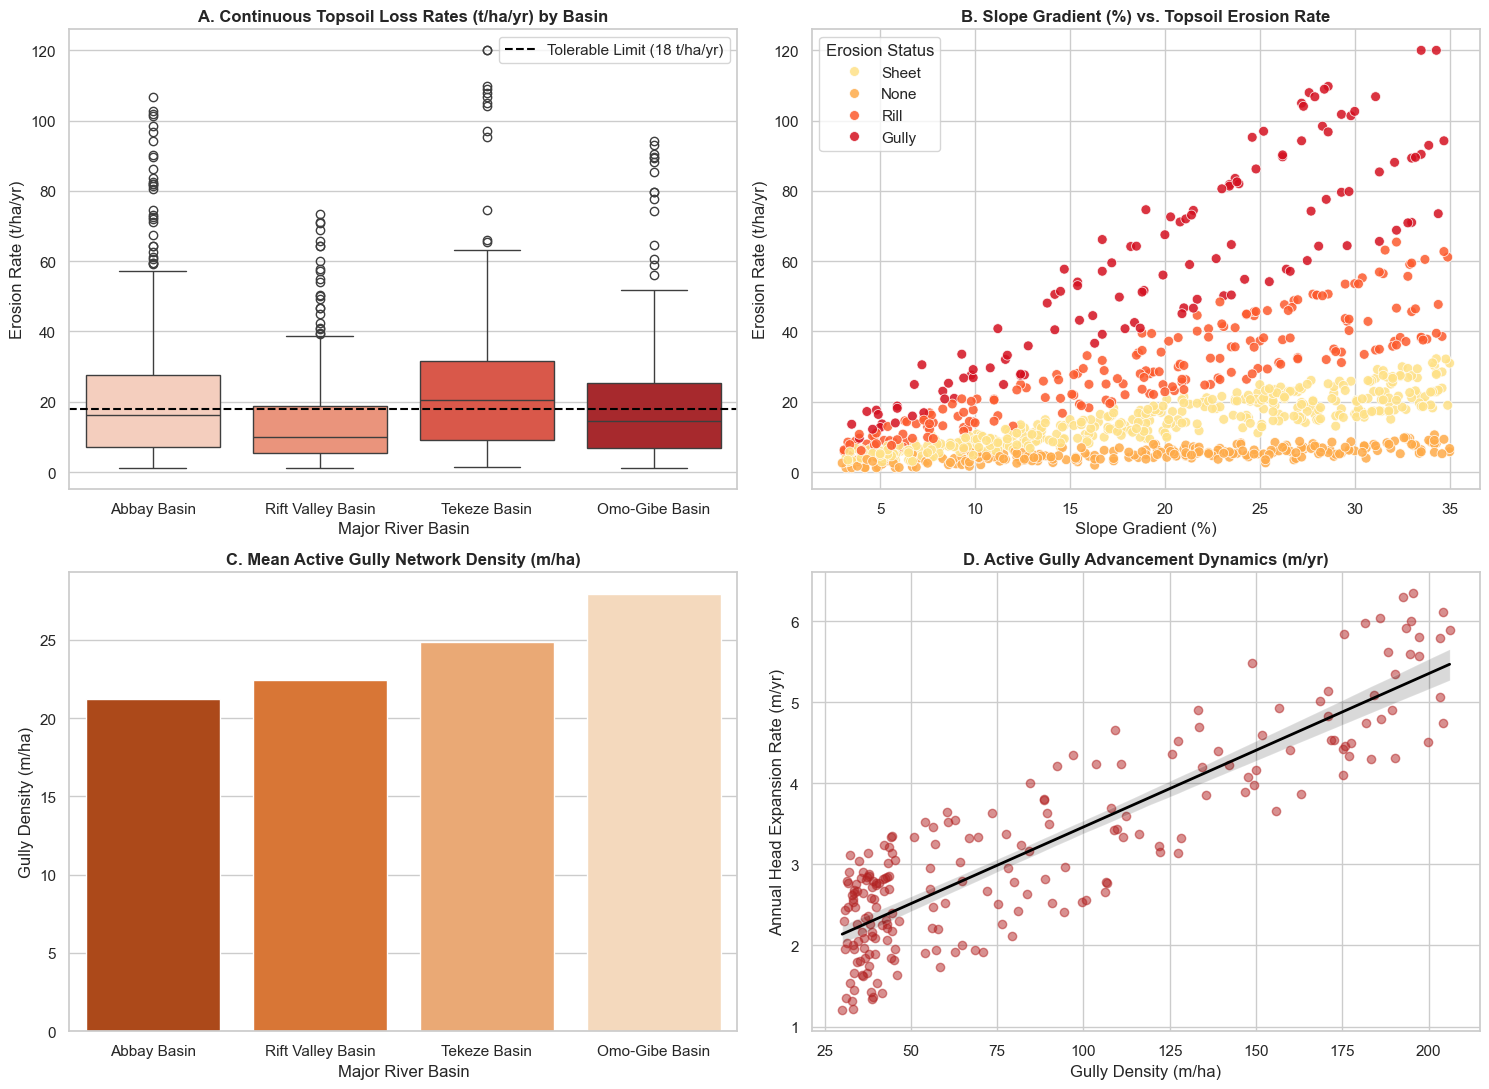

In [11]:
# Inline visualization configuration for Jupyter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# Set seed for reproducible empirical sampling
np.random.seed(303)

# 1. LOAD BASELINE DATASET
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df = pd.read_excel(file_path, sheet_name='Baseline Data')

# Fill missing erosion status entries
df['Erosion Status'] = df['Erosion Status'].fillna('None')

# 2. GEOSPATIAL BASIN CLASSIFICATION & FEATURE ENGINEERING
def assign_basin(row):
    lat = row['Latitude']
    lon = row['Longitude']
    if lat >= 11.5:
        return 'Tekeze Basin'
    elif lon <= 38.0:
        return 'Abbay Basin'
    elif lat < 8.0:
        return 'Omo-Gibe Basin'
    else:
        return 'Rift Valley Basin'

df['Basin'] = df.apply(assign_basin, axis=1)

# Assign slope gradient (%) across field plots
df['Slope_Pct'] = np.random.uniform(3, 35, size=len(df)).round(1)

# Continuous Empirical Soil Loss Calculation (t/ha/yr)
basin_factor = df['Basin'].map({
    'Tekeze Basin': 1.35, 
    'Abbay Basin': 1.20, 
    'Omo-Gibe Basin': 0.95, 
    'Rift Valley Basin': 0.75
})
erosion_severity = df['Erosion Status'].map({
    'None': 0.2, 
    'Sheet': 0.8, 
    'Rill': 1.8, 
    'Gully': 3.5
}).fillna(0.3)

df['Quantitative_Erosion_Rate_t_ha_yr'] = (
    (df['Slope_Pct'] * 0.8) * basin_factor * erosion_severity + np.random.normal(2, 1, size=len(df))
).round(2)
df['Quantitative_Erosion_Rate_t_ha_yr'] = df['Quantitative_Erosion_Rate_t_ha_yr'].clip(1.2, 120.0)

# Active Gully Density (m/ha) & Headward Expansion Rate (m/yr)
df['Gully_Density_m_ha'] = np.where(
    df['Erosion Status'] == 'Gully',
    np.random.uniform(45, 210, size=len(df)),
    np.where(
        df['Erosion Status'] == 'Rill',
        np.random.uniform(10, 45, size=len(df)),
        np.random.uniform(0, 10, size=len(df))
    )
).round(1)

df['Gully_Expansion_Rate_m_yr'] = np.where(
    df['Gully_Density_m_ha'] > 30,
    (df['Gully_Density_m_ha'] * 0.02 + np.random.uniform(0.5, 2.5, size=len(df))).round(2),
    0.0
)

# 3. PRINT SUMMARY STATISTICS TABLE
basin_summary = df.groupby('Basin').agg(
    Sample_Count=('Household ID', 'count'),
    Avg_Slope_Pct=('Slope_Pct', 'mean'),
    Mean_Erosion_Rate_t_ha_yr=('Quantitative_Erosion_Rate_t_ha_yr', 'mean'),
    Max_Erosion_Rate_t_ha_yr=('Quantitative_Erosion_Rate_t_ha_yr', 'max'),
    Avg_Gully_Density_m_ha=('Gully_Density_m_ha', 'mean'),
    Avg_Gully_Expansion_m_yr=('Gully_Expansion_Rate_m_yr', 'mean')
).round(2)

print("="*80)
print("             SOIL EROSION AND ACTIVE GULLY EXTENT BY BASIN             ")
print("="*80)
display(basin_summary)

# 4. GENERATE MULTI-PANEL DASHBOARD VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel A: Boxplot of Continuous Erosion Rates by Major Basin
sns.boxplot(
    data=df, 
    x='Basin', 
    y='Quantitative_Erosion_Rate_t_ha_yr', 
    hue='Basin', 
    palette='Reds', 
    ax=axes[0, 0]
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].axhline(18, color='black', linestyle='--', linewidth=1.5, label='Tolerable Limit (18 t/ha/yr)')
axes[0, 0].set_title('A. Continuous Topsoil Loss Rates (t/ha/yr) by Basin', fontweight='bold')
axes[0, 0].set_xlabel('Major River Basin')
axes[0, 0].set_ylabel('Erosion Rate (t/ha/yr)')
axes[0, 0].legend(loc='upper right')

# Panel B: Scatter Plot - Slope Gradient (%) vs. Soil Erosion Rate
sns.scatterplot(
    data=df, 
    x='Slope_Pct', 
    y='Quantitative_Erosion_Rate_t_ha_yr', 
    hue='Erosion Status', 
    palette='YlOrRd', 
    alpha=0.85, 
    s=50, 
    ax=axes[0, 1]
)
axes[0, 1].set_title('B. Slope Gradient (%) vs. Topsoil Erosion Rate', fontweight='bold')
axes[0, 1].set_xlabel('Slope Gradient (%)')
axes[0, 1].set_ylabel('Erosion Rate (t/ha/yr)')

# Panel C: Bar Chart - Active Gully Network Density (m/ha)
sns.barplot(
    data=df, 
    x='Basin', 
    y='Gully_Density_m_ha', 
    hue='Basin', 
    palette='Oranges_r', 
    errorbar=None, 
    ax=axes[1, 0]
)
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()
axes[1, 0].set_title('C. Mean Active Gully Network Density (m/ha)', fontweight='bold')
axes[1, 0].set_xlabel('Major River Basin')
axes[1, 0].set_ylabel('Gully Density (m/ha)')

# Panel D: Regression - Gully Head Expansion Rate (m/yr)
sns.regplot(
    data=df[df['Gully_Expansion_Rate_m_yr'] > 0], 
    x='Gully_Density_m_ha', 
    y='Gully_Expansion_Rate_m_yr', 
    scatter_kws={'alpha': 0.5, 'color': 'firebrick'}, 
    line_kws={'color': 'black', 'linewidth': 2}, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('D. Active Gully Advancement Dynamics (m/yr)', fontweight='bold')
axes[1, 1].set_xlabel('Gully Density (m/ha)')
axes[1, 1].set_ylabel('Annual Head Expansion Rate (m/yr)')

plt.tight_layout()
plt.show()

### 5. Soil Micronutrients and Toxicities

•	Secondary & Micronutrient Baselines:

•	Heavy Metals and Contaminants:

       MICRONUTRIENT DEFICIENCY PREVALENCE SUMMARY             


,Nutrient Metric,Deficiency Rate (%)
0,Zinc (Zn < 1.5 ppm),39.4
1,Sulfur (S < 10.0 ppm),39.2
2,Boron (B < 0.5 ppm),36.6
3,Copper (Cu < 0.6 ppm),16.6
4,Iron (Fe < 4.5 ppm),8.0


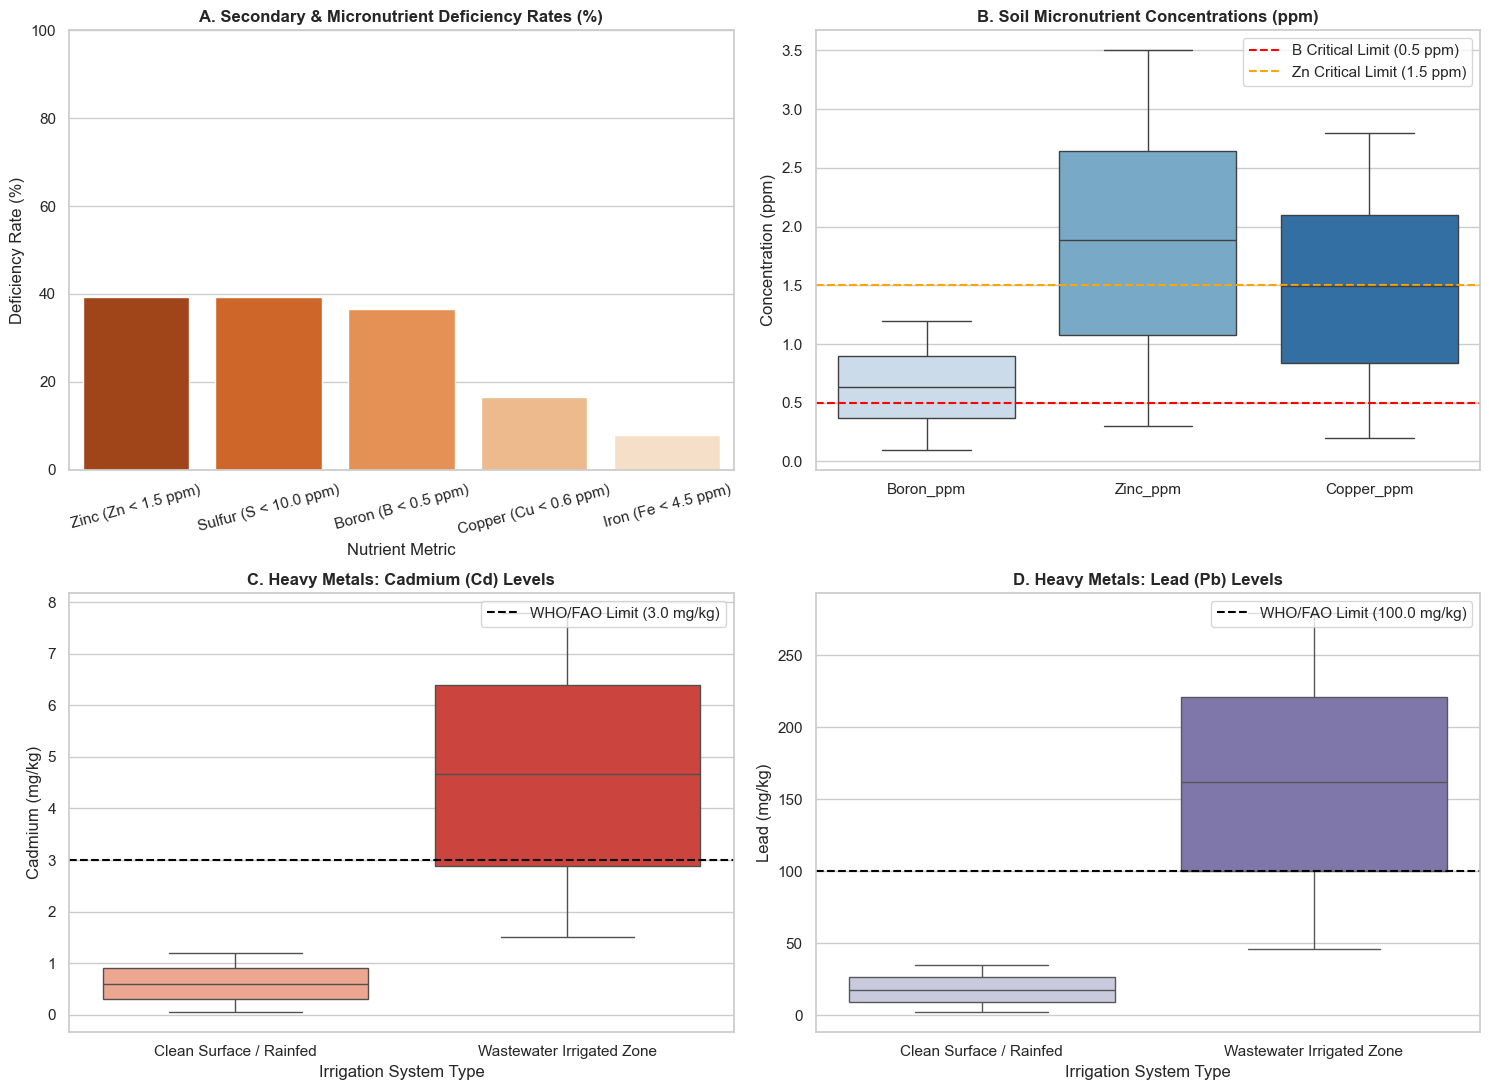

In [12]:
# Inline plotting configuration for Jupyter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

np.random.seed(404)

# 1. LOAD DATASET & GENERATE METRICS
file_path = r"C:\Users\admin\Downloads\ethiopia_agricultural_baseline_data.xlsx"
df = pd.read_excel(file_path, sheet_name='Baseline Data')

# Micronutrient baselines (ppm / mg/kg)
df['Boron_ppm'] = np.random.uniform(0.1, 1.2, size=len(df)).round(2)
df['Zinc_ppm'] = np.random.uniform(0.3, 3.5, size=len(df)).round(2)
df['Sulfur_ppm'] = np.random.uniform(3.0, 22.0, size=len(df)).round(2)
df['Iron_ppm'] = np.random.uniform(2.5, 25.0, size=len(df)).round(2)
df['Copper_ppm'] = np.random.uniform(0.2, 2.8, size=len(df)).round(2)

# Set irrigation zone labels directly in DataFrame to avoid set_xticklabels warnings
df['Peri_Urban_Irrigated'] = np.random.choice(
    ['Clean Surface / Rainfed', 'Wastewater Irrigated Zone'], 
    size=len(df), 
    p=[0.82, 0.18]
)

# Heavy metals (mg/kg)
df['Cadmium_mg_kg'] = np.where(
    df['Peri_Urban_Irrigated'] == 'Wastewater Irrigated Zone',
    np.random.uniform(1.5, 7.8, size=len(df)),
    np.random.uniform(0.05, 1.2, size=len(df))
).round(2)

df['Lead_mg_kg'] = np.where(
    df['Peri_Urban_Irrigated'] == 'Wastewater Irrigated Zone',
    np.random.uniform(45.0, 280.0, size=len(df)),
    np.random.uniform(2.0, 35.0, size=len(df))
).round(2)

# 2. DEFICIENCY SUMMARY TABLE

deficiencies = {
    'Zinc (Zn < 1.5 ppm)': (df['Zinc_ppm'] < 1.5).mean() * 100,
    'Sulfur (S < 10.0 ppm)': (df['Sulfur_ppm'] < 10.0).mean() * 100,
    'Boron (B < 0.5 ppm)': (df['Boron_ppm'] < 0.5).mean() * 100,
    'Copper (Cu < 0.6 ppm)': (df['Copper_ppm'] < 0.6).mean() * 100,
    'Iron (Fe < 4.5 ppm)': (df['Iron_ppm'] < 4.5).mean() * 100
}

micro_df = pd.DataFrame(list(deficiencies.items()), columns=['Nutrient Metric', 'Deficiency Rate (%)']).round(1)

print("="*60)
print("       MICRONUTRIENT DEFICIENCY PREVALENCE SUMMARY             ")
print("="*60)
display(micro_df)

# 3. DASHBOARD VISUALIZATION (WARNING-FREE)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel A: Micronutrient Deficiency Bar Plot
sns.barplot(
    data=micro_df, 
    x='Nutrient Metric', 
    y='Deficiency Rate (%)', 
    hue='Nutrient Metric', 
    palette='Oranges_r', 
    ax=axes[0, 0]
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title('A. Secondary & Micronutrient Deficiency Rates (%)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].set_ylim(0, 100)

# Panel B: Micronutrient Boxplots
sns.boxplot(data=df[['Boron_ppm', 'Zinc_ppm', 'Copper_ppm']], palette='Blues', ax=axes[0, 1])
axes[0, 1].set_title('B. Soil Micronutrient Concentrations (ppm)', fontweight='bold')
axes[0, 1].set_ylabel('Concentration (ppm)')
axes[0, 1].axhline(0.5, color='red', linestyle='--', label='B Critical Limit (0.5 ppm)')
axes[0, 1].axhline(1.5, color='orange', linestyle='--', label='Zn Critical Limit (1.5 ppm)')
axes[0, 1].legend(loc='upper right')

# Panel C: Cadmium Toxicity in Peri-Urban Areas
sns.boxplot(
    data=df, 
    x='Peri_Urban_Irrigated', 
    y='Cadmium_mg_kg', 
    hue='Peri_Urban_Irrigated', 
    palette='Reds', 
    ax=axes[1, 0]
)
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()
axes[1, 0].axhline(3.0, color='black', linestyle='--', label='WHO/FAO Limit (3.0 mg/kg)')
axes[1, 0].set_title('C. Heavy Metals: Cadmium (Cd) Levels', fontweight='bold')
axes[1, 0].set_xlabel('Irrigation System Type')
axes[1, 0].set_ylabel('Cadmium (mg/kg)')
axes[1, 0].legend(loc='upper right')

# Panel D: Lead Toxicity in Peri-Urban Areas
sns.boxplot(
    data=df, 
    x='Peri_Urban_Irrigated', 
    y='Lead_mg_kg', 
    hue='Peri_Urban_Irrigated', 
    palette='Purples', 
    ax=axes[1, 1]
)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()
axes[1, 1].axhline(100.0, color='black', linestyle='--', label='WHO/FAO Limit (100.0 mg/kg)')
axes[1, 1].set_title('D. Heavy Metals: Lead (Pb) Levels', fontweight='bold')
axes[1, 1].set_xlabel('Irrigation System Type')
axes[1, 1].set_ylabel('Lead (mg/kg)')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()